# Spotify Genre Classification (Multiclass)

**Goal:** predict a track's genre from its audio features.

- **Dataset:** [maharshipandya/spotify-tracks-dataset](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset) on Hugging Face (~114k tracks, 125 genres)
- **Classes:** `classical`, `hip-hop`, `heavy-metal`, `country`, `edm`
- **Models:** Logistic Regression, Decision Tree, Random Forest, k-Nearest Neighbours, SVM, each in a `Pipeline` with `StandardScaler`
- **Evaluation:** accuracy, precision, recall, F1 (macro), confusion matrices
- **Tuning:** `GridSearchCV` on Random Forest
- **Deployment:** models saved with `joblib` and used by the Streamlit app in `app.py`

## 1. Imports

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
GENRES = ["classical", "hip-hop", "heavy-metal", "country", "edm"]
SAMPLE_PER_GENRE = 1500
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
sns.set_theme(style="whitegrid")

/opt/miniconda3/envs/condavenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the dataset from Hugging Face

In [2]:
raw = load_dataset("maharshipandya/spotify-tracks-dataset", split="train").to_pandas()
raw = raw.drop(columns=["Unnamed: 0"], errors="ignore")
print(raw.shape)
raw.head()

(114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

In [4]:
print("Missing values per column:")
print(raw.isna().sum()[raw.isna().sum() > 0])
print("\nDuplicate track_ids:", raw["track_id"].duplicated().sum())

Missing values per column:
artists       1
album_name    1
track_name    1
dtype: int64

Duplicate track_ids: 24259


## 3. Clean, filter and sample

1. **Drop duplicate `track_id`s** across the full dataset. The same song often appears under several genres, and keeping every copy would put identical feature vectors in both train and test with different labels.
2. **Filter** to the 5 target genres.
3. **Sample** up to `SAMPLE_PER_GENRE` tracks per genre.

> **Note:** the dataset has only **1,000 tracks per genre**, and dropping duplicates across all 125 genres leaves fewer than that (a track keeps the genre of its first occurrence). Because 1,500 per genre isn't available, `min(1500, available)` keeps every remaining track. The classes end up slightly imbalanced, so a stratified split and **macro-averaged** metrics are used.

In [5]:
df = raw.drop_duplicates(subset="track_id", keep="first")
print(f"After dropping duplicate track_ids: {len(df):,} rows (removed {len(raw) - len(df):,})")

df = df[df["track_genre"].isin(GENRES)]
print("Available per genre after filtering:")
print(df["track_genre"].value_counts())

df = pd.concat(
    [g.sample(n=min(SAMPLE_PER_GENRE, len(g)), random_state=RANDOM_STATE) for _, g in df.groupby("track_genre")]
).reset_index(drop=True)
print(f"\nFinal sample: {len(df):,} tracks")
df["track_genre"].value_counts()

After dropping duplicate track_ids: 89,741 rows (removed 24,259)
Available per genre after filtering:
track_genre
heavy-metal    997
country        946
classical      867
hip-hop        842
edm            694
Name: count, dtype: int64

Final sample: 4,346 tracks


track_genre
heavy-metal    997
country        946
classical      867
hip-hop        842
edm            694
Name: count, dtype: int64

### Feature selection
Only the **audio features** are used, the numbers a user can realistically set with sliders in the app.
`popularity`, `explicit` and text columns (artist, album, track name) are excluded. They aren't properties of the sound, and the text columns would let the models identify tracks by artist instead of learning from the audio.

In [6]:
FEATURES = ["danceability", "energy", "loudness", "speechiness", "acousticness",
            "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]
TARGET = "track_genre"

X = df[FEATURES]
y = df[TARGET]
X.describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,4346.0,0.542171,0.178241,0.076900,0.42000,0.542000,0.677000,0.964
energy,4346.0,0.623375,0.285420,0.000756,0.45200,0.695000,0.855750,0.998
loudness,4346.0,-8.881776,6.847041,-41.531000,-9.68600,-6.291000,-4.716250,0.175
speechiness,4346.0,0.073767,0.068482,0.023200,0.03610,0.048500,0.080700,0.766
acousticness,4346.0,0.316637,0.368598,0.000002,0.00897,0.121500,0.615000,0.996
instrumentalness,4346.0,0.147968,0.311206,0.000000,0.00000,0.000019,0.019875,0.984
liveness,4346.0,0.205479,0.176255,0.022600,0.09900,0.131000,0.259750,0.986
valence,4346.0,0.459753,0.228319,0.000000,0.28500,0.453000,0.625000,0.977
tempo,4346.0,120.021376,29.630798,35.928000,96.44800,120.050000,140.005000,214.016
duration_ms,4346.0,219991.540957,118053.131675,17453.000000,170045.00000,205880.000000,247537.000000,2646866.000


## 4. Exploratory data analysis

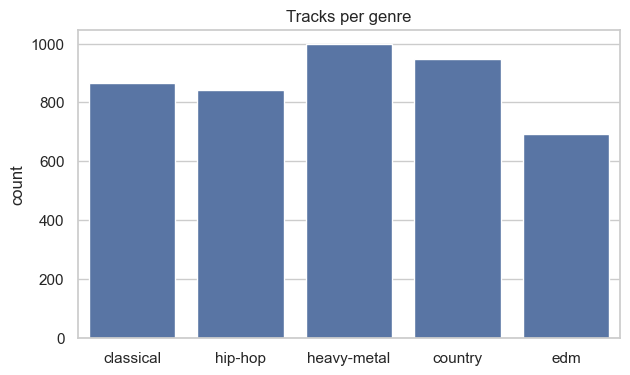

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x=TARGET, order=GENRES, ax=ax)
ax.set_title("Tracks per genre"); ax.set_xlabel(""); plt.show()

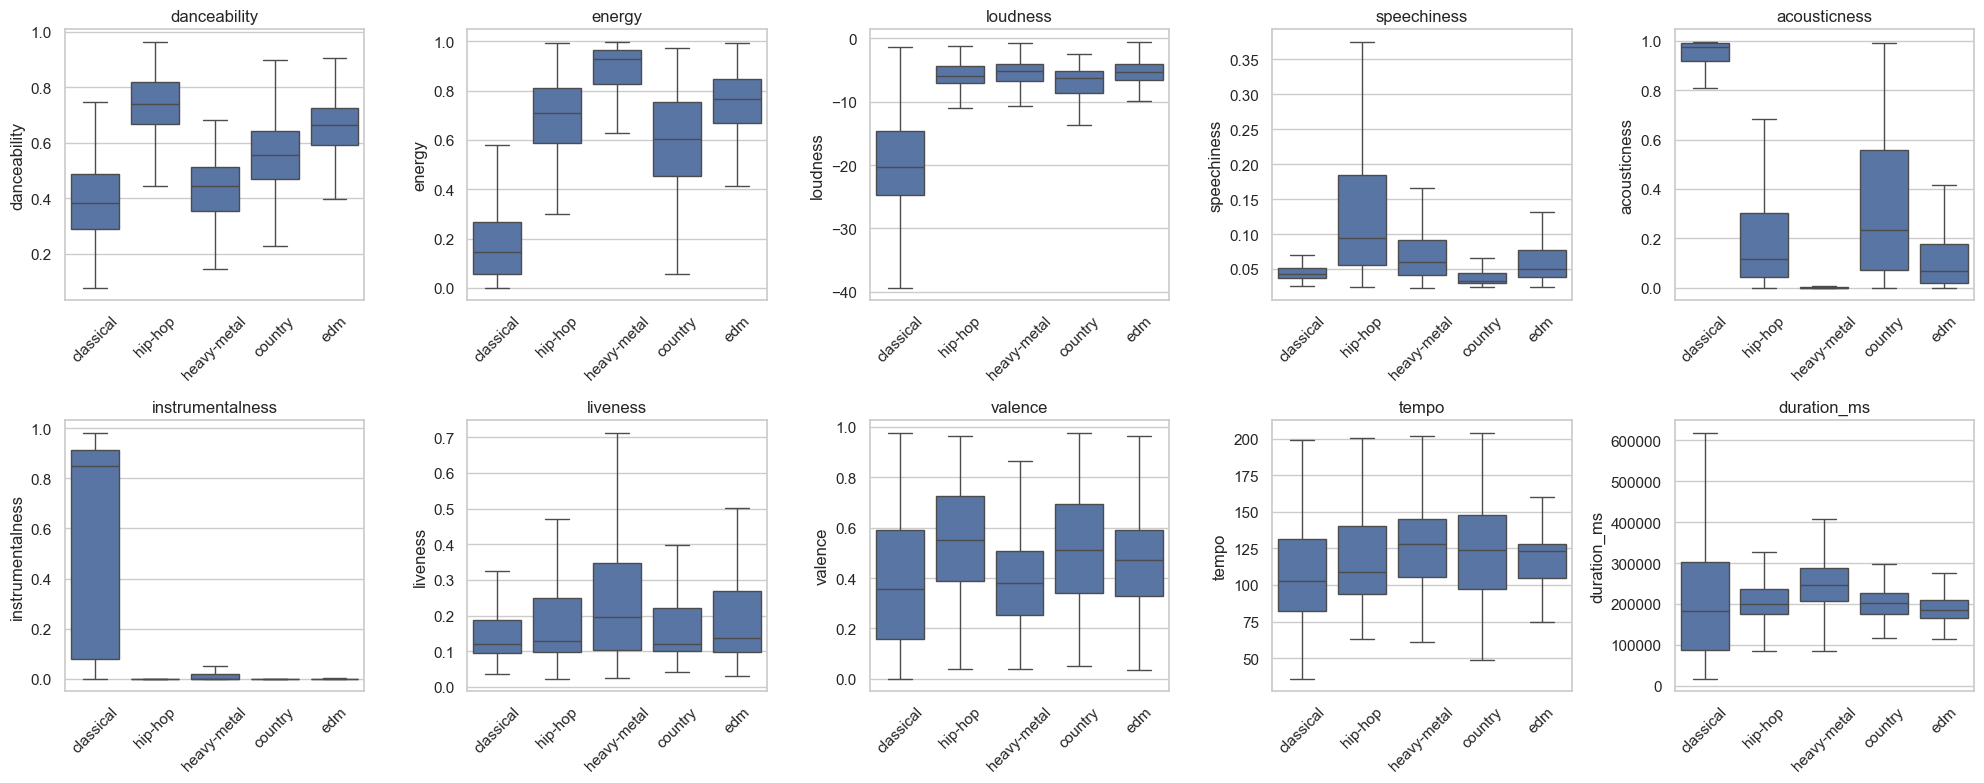

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, feat in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=df, x=TARGET, y=feat, order=GENRES, ax=ax, showfliers=False)
    ax.set_title(feat); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

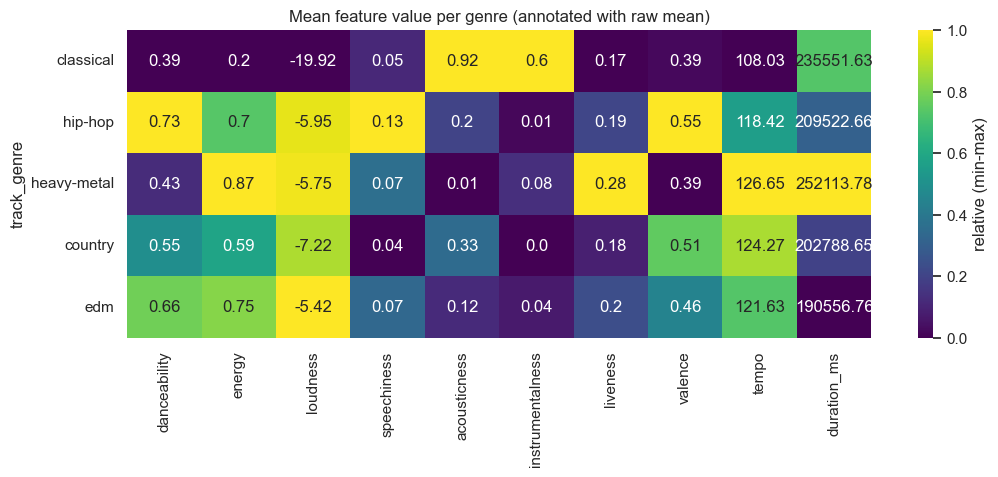

In [9]:
genre_means = df.groupby(TARGET)[FEATURES].mean().loc[GENRES]
# Scale each feature to 0-1 so the heatmap colours are comparable across features
norm = (genre_means - genre_means.min()) / (genre_means.max() - genre_means.min())
plt.figure(figsize=(12, 4))
sns.heatmap(norm, annot=genre_means.round(2), fmt="", cmap="viridis", cbar_kws={"label": "relative (min-max)"})
plt.title("Mean feature value per genre (annotated with raw mean)"); plt.show()

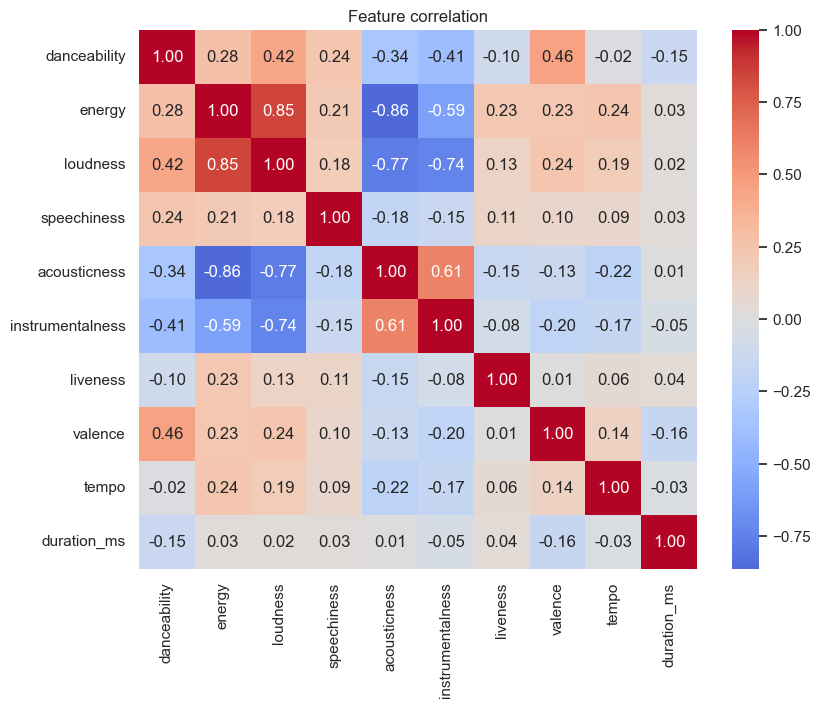

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation"); plt.show()

## 5. Train / test split (stratified 80/20)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (3476, 10)  Test: (870, 10)


## 6. Build and train the models
Every model is a `Pipeline([StandardScaler, classifier])`, so the scaler is fit on the training data only and the same preprocessing runs at prediction time in the app.
Scaling matters for LR, kNN and SVM. It has no effect on the tree models, but keeping them in the same pipeline shape keeps the app code simple.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "kNN":                 KNeighborsClassifier(n_neighbors=7),
    "SVM":                 SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}
pipelines = {name: Pipeline([("scaler", StandardScaler()), ("clf", clf)]) for name, clf in models.items()}

def evaluate(name, model):
    pred = model.predict(X_test)
    return {
        "Model": name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="macro"),
        "Recall":    recall_score(y_test, pred, average="macro"),
        "F1":        f1_score(y_test, pred, average="macro"),
    }

results = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    results.append(evaluate(name, pipe))

results_df = pd.DataFrame(results).set_index("Model").sort_values("F1", ascending=False)
results_df.style.format("{:.4f}").highlight_max(color="lightgreen")

/opt/miniconda3/envs/condavenv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Accuracy,Precision,Recall,F1
Model,,,,
Random Forest,0.8598,0.8559,0.8522,0.8532
SVM,0.8023,0.7979,0.7892,0.7908
Decision Tree,0.7793,0.7717,0.7701,0.7705
Logistic Regression,0.7747,0.7682,0.7602,0.7612
kNN,0.7701,0.7710,0.7581,0.7611


## 7. Evaluation
### Per-class classification reports

In [13]:
for name, pipe in pipelines.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, pipe.predict(X_test), labels=GENRES, digits=3))

===== Logistic Regression =====
              precision    recall  f1-score   support

   classical      0.925     0.925     0.925       174
     hip-hop      0.760     0.661     0.707       168
 heavy-metal      0.831     0.910     0.869       200
     country      0.670     0.772     0.717       189
         edm      0.655     0.532     0.587       139

    accuracy                          0.775       870
   macro avg      0.768     0.760     0.761       870
weighted avg      0.773     0.775     0.771       870

===== Decision Tree =====
              precision    recall  f1-score   support

   classical      0.935     0.914     0.924       174
     hip-hop      0.696     0.655     0.675       168
 heavy-metal      0.877     0.855     0.866       200
     country      0.739     0.794     0.765       189
         edm      0.611     0.633     0.622       139

    accuracy                          0.779       870
   macro avg      0.772     0.770     0.770       870
weighted avg      0

### Confusion matrices

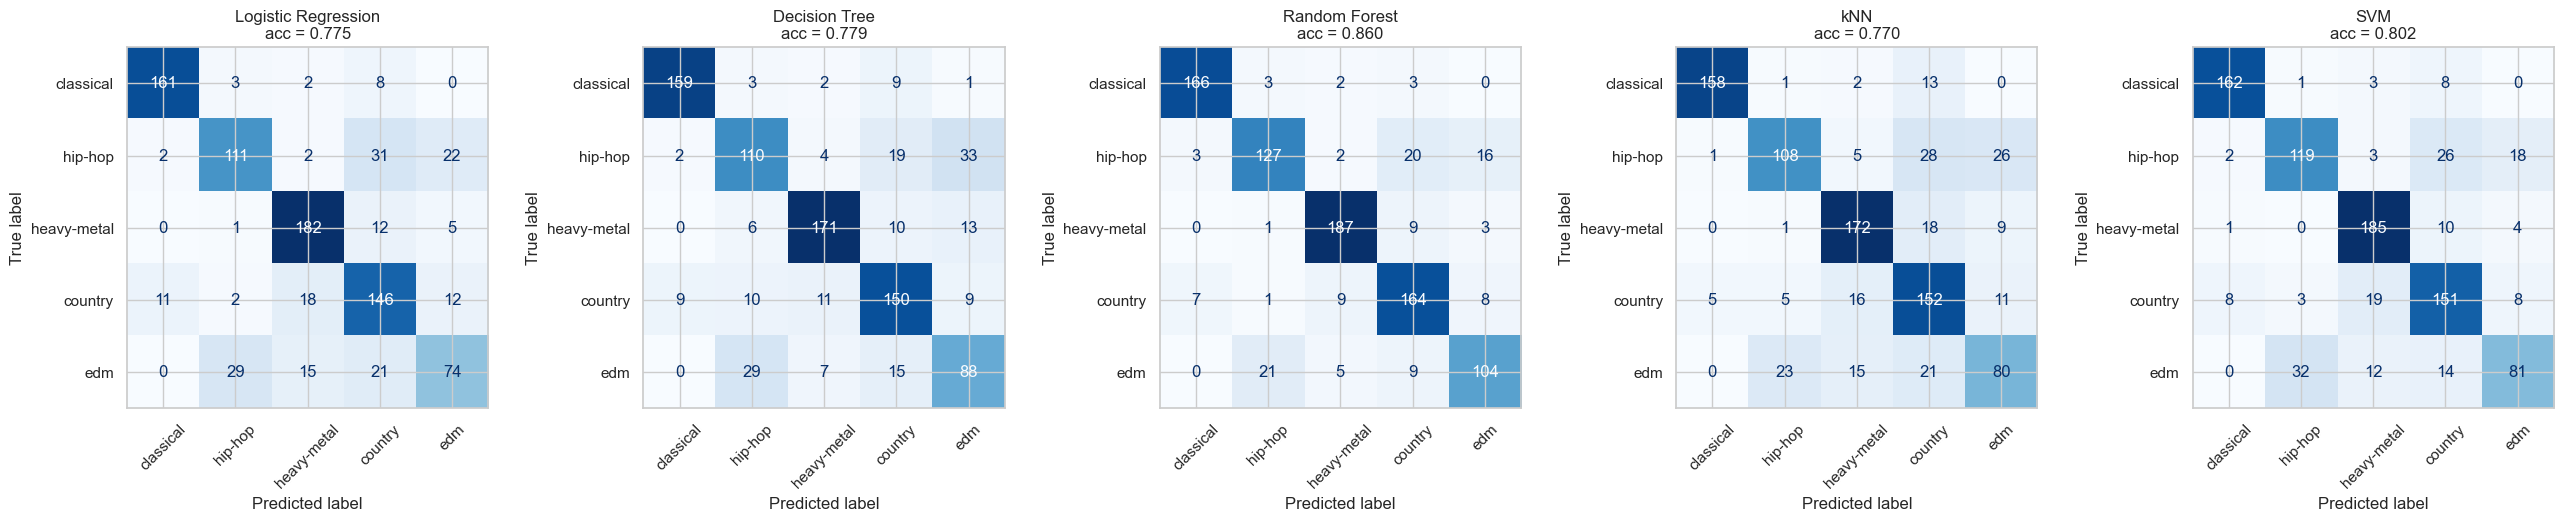

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test), labels=GENRES)
    ConfusionMatrixDisplay(cm, display_labels=GENRES).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"{name}\nacc = {results_df.loc[name, 'Accuracy']:.3f}")
plt.tight_layout(); plt.show()

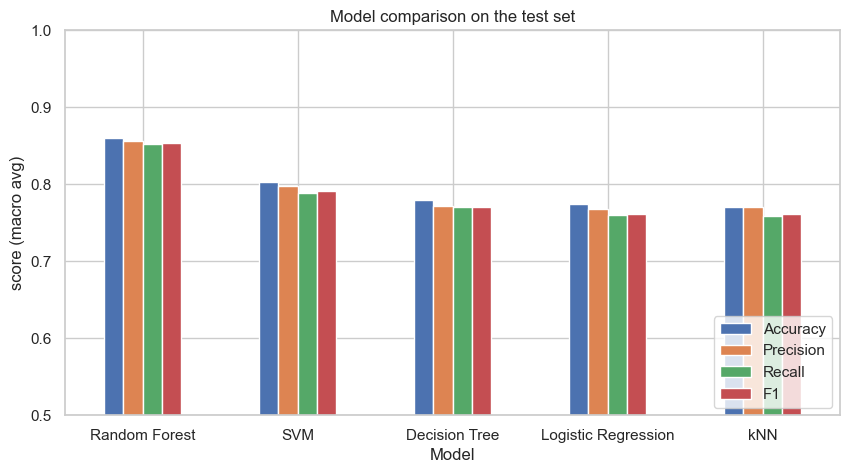

In [15]:
ax = results_df.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("score (macro avg)"); ax.set_title("Model comparison on the test set")
ax.legend(loc="lower right"); plt.show()

## 8. Hyperparameter tuning: GridSearchCV on Random Forest
5-fold stratified CV on the **training set only**, scored by macro F1. The test set stays untouched until the final comparison.

In [16]:
param_grid = {
    "clf__n_estimators":      [200, 400],
    "clf__max_depth":         [None, 10, 20],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf":  [1, 2],
    "clf__max_features":      ["sqrt", "log2"],
}
grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))]),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro", n_jobs=-1, verbose=1,
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print(f"Best CV macro-F1: {grid.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


Best params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
Best CV macro-F1: 0.8518


In [17]:
best_rf = grid.best_estimator_
pipelines["Random Forest (tuned)"] = best_rf
results_df = pd.concat([results_df, pd.DataFrame([evaluate("Random Forest (tuned)", best_rf)]).set_index("Model")])
results_df = results_df.sort_values("F1", ascending=False)
results_df.style.format("{:.4f}").highlight_max(color="lightgreen")

,Accuracy,Precision,Recall,F1
Model,,,,
Random Forest (tuned),0.8598,0.8565,0.8526,0.8537
Random Forest,0.8598,0.8559,0.8522,0.8532
SVM,0.8023,0.7979,0.7892,0.7908
Decision Tree,0.7793,0.7717,0.7701,0.7705
Logistic Regression,0.7747,0.7682,0.7602,0.7612
kNN,0.7701,0.7710,0.7581,0.7611


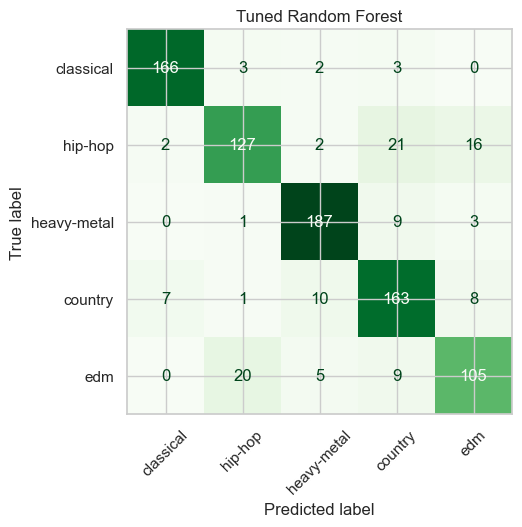

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, labels=GENRES, cmap="Greens",
                                      colorbar=False, xticks_rotation=45, ax=ax)
ax.set_title("Tuned Random Forest"); plt.show()

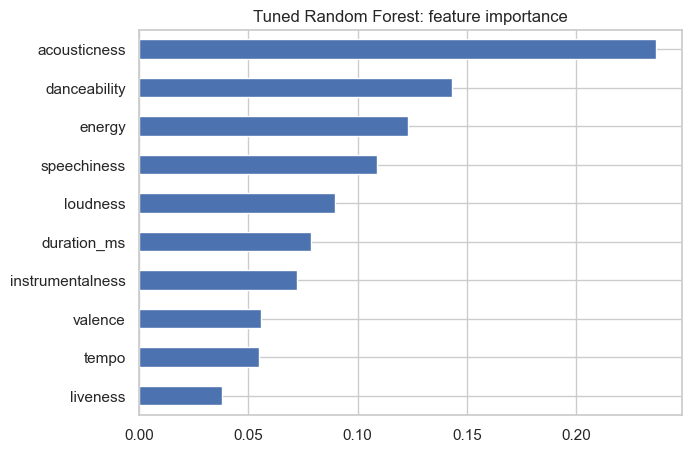

In [19]:
importances = pd.Series(best_rf.named_steps["clf"].feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", figsize=(7, 5), title="Tuned Random Forest: feature importance"); plt.show()

## 9. Save the models with joblib

In [20]:
def slug(name):
    return name.lower().replace(" ", "_").replace("(", "").replace(")", "")

model_files = {}
for name, pipe in pipelines.items():
    path = os.path.join(MODEL_DIR, f"{slug(name)}.joblib")
    joblib.dump(pipe, path)
    model_files[name] = path

# Metadata the Streamlit app needs: feature order, slider ranges, class labels, test scores
metadata = {
    "features": FEATURES,
    "genres": GENRES,
    "feature_stats": df[FEATURES].describe().T[["min", "max", "50%"]].rename(columns={"50%": "median"}).to_dict("index"),
    "genre_means": genre_means.to_dict("index"),
    "results": results_df.round(4).to_dict("index"),
    "model_files": model_files,
    "best_rf_params": grid.best_params_,
}
joblib.dump(metadata, os.path.join(MODEL_DIR, "metadata.joblib"))
print("Saved:", *sorted(os.listdir(MODEL_DIR)), sep="\n  ")

Saved:
  decision_tree.joblib
  knn.joblib
  logistic_regression.joblib
  metadata.joblib
  random_forest.joblib
  random_forest_tuned.joblib
  svm.joblib


In [21]:
# Check: reload a saved model and confirm it gives the same predictions
reloaded = joblib.load(model_files["Random Forest (tuned)"])
assert (reloaded.predict(X_test) == best_rf.predict(X_test)).all()
print("Reloaded model matches.")

Reloaded model matches.


## 10. Conclusions
- **Random Forest is the best model** (≈0.86 accuracy, ≈0.85 macro F1), followed by SVM (≈0.80). Logistic Regression, the Decision Tree and kNN all score around 0.77.
- **GridSearchCV** picked `n_estimators=400, max_depth=None, max_features='sqrt'`. This is close to the default configuration, so tuning gave almost no gain (macro F1 0.8532 → 0.8537). The default Random Forest was already near its best on these features.
- **Classical** (F1 ≈ 0.95) and **heavy-metal** (≈ 0.92) are the easiest genres. Classical is quiet, acoustic and instrumental. Heavy-metal combines the highest energy with low danceability.
- **EDM** (≈ 0.77) and **hip-hop** (≈ 0.79) are the hardest. They are mostly confused with each other and with country, because all three are loud, energetic and danceable. Hip-hop's high speechiness is its main distinguishing feature.
- All pipelines are saved in `models/` and loaded by `app.py` (`streamlit run app.py`).